# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Arbaz Ferdiansah
- **Email:** doozyarbaz@gmail.com
- **ID Dicoding:** arbaz_ferdiansah

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren revenue bulanan pada Januari 2017 - Agustus 2018, dan kategori produk apa saja yang menyumbang revenue tertinggi dan terendah?
- **Pertanyaan 2:** Seberapa besar keterlambatan pengiriman menurunkan rata-rata review score pelanggan pada Janurari 2017 - Agustus 2018, dan di state mana pesanan paling sering terlambat?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Mengimpor library yang diperlukan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Data Wrangling

### Gathering Data

#### Load df customers, orders, order_items, order_reviews, products, product_category_name_translation

In [2]:
# Membaca file customers, lalu menampilkan 5 baris pertama
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
# Membaca file orders, lalu menampilkan 5 baris pertama
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
# Membaca file order_items, lalu menampilkan 5 baris pertama
items_df = pd.read_csv("order_items_dataset.csv")
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
# Membaca file order_reviews, lalu menampilkan 5 baris pertama
reviews_df = pd.read_csv("order_reviews_dataset.csv")
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [6]:
# Membaca file products, lalu menampilkan 5 baris pertama
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
# Membaca file terjemahan kategori produk, lalu menampilkan 5 baris pertama
translation_df = pd.read_csv("product_category_name_translation.csv")
translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:** (Opsional)
- Enam tabel berhasil dimuat: `customers` (99.441 baris), `orders` (99.441), `order_items` (112.650), `order_reviews` (99.224), `products` (32.951), dan terjemahan kategori (71).
- Tabel terhubung lewat `customer_id` (customers-orders), `order_id` (orders-items-reviews), dan `product_id` (items-products).
- Satu order bisa punya beberapa item, jadi `order_items` lebih banyak barisnya daripada `orders`.

### Assessing Data

#### Identifying customers_df, orders_df, items_df, reviews_df, products_df, translation_df

Menilai tabel `customers_df`

In [8]:
# Melihat tipe data dan jumlah data tiap kolom
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [9]:
# Melihat ringkasan angka (min, max, rata-rata) tiap kolom angka
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [10]:
# Menghitung jumlah nilai kosong (missing value) tiap kolom
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [11]:
# Menghitung jumlah data duplikat
print(F"Jumlah duplikasi: {customers_df.duplicated().sum()}")


Jumlah duplikasi: 0


Menilai tabel `orders_df`

In [12]:
# Melihat tipe data dan jumlah data tiap kolom
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [13]:
# Melihat ringkasan data tiap kolom
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [14]:
# Menghitung jumlah nilai kosong (missing value) tiap kolom
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
# Menghitung jumlah data duplikat
print(f"Jumlah duplikasi: {orders_df.duplicated().sum()}")

Jumlah duplikasi: 0


In [16]:
# Melihat jumlah order untuk tiap status
orders_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [17]:
# Order berstatus delivered tetapi tanggal tiba ke pelanggan kosong
orders_df[(orders_df["order_status"] == "delivered") & (orders_df["order_delivered_customer_date"].isna())].shape[0]

8

In [18]:
# Melihat jumlah order tiap bulan (untuk mengecek rentang waktu data)
pd.to_datetime(orders_df['order_purchase_timestamp']).dt.to_period('M').value_counts().sort_index()

,count
order_purchase_timestamp,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


Menilai tabel `items_df`

In [19]:
# Melihat tipe data dan jumlah data tiap kolom
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [20]:
# Melihat ringkasan angka
items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [21]:
# Menghitung jumlah nilai kosong (missing value) tiap kolom
items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [22]:
# Menghitung jumlah data duplikat
print(f"Jumlah duplikasi: {items_df.duplicated().sum()}")

Jumlah duplikasi: 0


Menilai tabel `reviews_df`

In [23]:
# Melihat tipe data dan jumlah data tiap kolom
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [24]:
# Melihat ringkasan angka (review score)
reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [25]:
# Menghitung jumlah nilai kosong (missing value) tiap kolom
reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [26]:
# Menghitung jumlah data duplikat
print(f"Jumlah duplkasi: {reviews_df.duplicated().sum()}")

Jumlah duplkasi: 0


In [27]:
# Menghitung order yang punya lebih dari 1 review
print(f"Order dengan lebih dari 1 review: {reviews_df['order_id'].duplicated().sum()}")

Order dengan lebih dari 1 review: 551


Menilai tabel `products_df`

In [28]:
# Melihat tipe data dan jumlah data tiap kolom
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [29]:
# Melihat ringkasan angka tiap kolom angka
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [30]:
# Menghitung jumlah nilai kosong (missing value) tiap kolom
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [31]:
# Menghitung jumlah data duplikat
print(f"Jumlah duplikasi: {products_df.duplicated().sum()}")

Jumlah duplikasi: 0


Menilai tabel `translation_df`

In [32]:
# Melihat tipe data dan jumlah data tiap kolom
translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [33]:
# Menghitung jumlah data duplikat
print(f"Jumlah duplikasi: {translation_df.duplicated().sum()}")

Jumlah duplikasi: 0


In [34]:
# kategori pada products yang tidak ada di tabel terjemahan
set(products_df.product_category_name.dropna()) - set(translation_df.product_category_name)

{'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}

**Rangkuman masalah yang ditemukan:**

| | Tipe data | Missing value | Duplicate data | Inaccurate/inconsistent value |
|---|---|---|---|---|
| customers_df | - | - | - | - |
| orders_df | Kolom tanggal bertipe object | Tanggal tiba kosong pada 2.965 order | - | Status non-delivered; data sebelum Jan 2017 dan setelah Agu 2018 sangat sedikit |
| items_df | - | - | - | - |
| products_df | - | 610 produk tanpa kategori | - | 2 kategori tidak ada terjemahannya |
| reviews_df | - | - | 551 order punya lebih dari 1 review | - |

**Steps to Take:**
- `orders_df`: ubah kolom tanggal menjadi datetime; ambil hanya order `delivered` yang punya tanggal tiba pada periode Januari 2017 - Agustus 2018.
- `products_df`: isi kategori kosong dengan `unknown` dan lengkapi 2 terjemahan kategori yang hilang.
- `reviews_df`: simpan satu review per order (hapus duplikat `order_id`).

**Insight:** (Opsional)
- Tabel `customers` sudah bersih.
- Tabel `order_items` tidak punya nilai kosong atau duplikat. Ada harga yang sangat besar (maksimal 6.735), tetapi masih wajar untuk barang mahal, jadi dibiarkan.
- Masalah paling banyak ada di `orders` (tipe data tanggal dan tanggal tiba kosong), `products` (610 kategori kosong), dan `order_reviews` (551 order punya lebih dari 1 review).
- Data sebelum Januari 2017 dan setelah Agustus 2018 sangat sedikit, jadi analisis dibatasi di Januari 2017 - Agustus 2018.

### Cleaning Data

#### Fixing orders_df, products_df, reviews_df problem

Membersihkan tabel `orders_df`

In [35]:
# Mengubah kolom tanggal dari teks (object) menjadi datetime
datetime_columns = ['order_purchase_timestamp',
                    'order_delivered_customer_date',
                    'order_estimated_delivery_date']

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(5)
memory usage: 6.1+ MB


In [36]:
# Ambil order yang berstatus delivered, punya tanggal tiba, dan dibeli Jan 2017 - Agu 2018
orders_df = orders_df[orders_df.order_status == "delivered"]
orders_df = orders_df.dropna(subset=["order_delivered_customer_date"])
orders_df = orders_df[(orders_df.order_purchase_timestamp >= "2017-01-01") & (orders_df.order_purchase_timestamp < "2018-09-01")]
print("Jumlah order: ", len(orders_df))

Jumlah order:  96203


Membersihkan tabel `products_df`

In [37]:
# Mengisi kategori produk yang kosong dengan 'unknown'
products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

In [38]:
# tambahkan 2 terjemahan yang hilang
translation_df = pd.concat([translation_df, pd.DataFrame({
    "product_category_name": ["pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos"],
    "product_category_name_english": ["pc_gamer", "portable_kitchen_food_preparers"]
})], ignore_index=True)

products_df = pd.merge(
    left=products_df[["product_id", "product_category_name"]],
    right=translation_df,
    how="left",
    on="product_category_name"
)
products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_category_name_english,0


Membersihkan tabel `reviews_df`

In [39]:
# Menyisakan satu review untuk setiap order
reviews_df.drop_duplicates(subset="order_id", keep="last", inplace=True)
print("Order dengan lebih dari 1 review: ", reviews_df.order_id.duplicated().sum())

Order dengan lebih dari 1 review:  0


**Insight:** (Opsional)
- Setelah dibersihkan, tersisa 96.203 order yang sudah sampai ke pelanggan dan dipakai untuk analisis.
- Setiap order sekarang hanya punya satu review sehingga dapat digabung dengan tabel lain.
- Kategori produk yang kosong diberi nama `unknown`, dan 2 kategori yang belum ada terjemahannya sudah dilengkapi.

## Exploratory Data Analysis (EDA)

### Explore customers_df, orders_df, items_df, reviews_df, products_df, translation_df

Explore data `orders_df`

In [40]:
# Membuat kolom delay_days (selisih hari tiba dengan estimasi) dan is_late (True jika terlambat)
orders_df["delay_days"] = (orders_df["order_delivered_customer_date"] - orders_df["order_estimated_delivery_date"]).dt.days
orders_df["is_late"] = orders_df["delay_days"] > 0
orders_df[["order_id", "order_purchase_timestamp", "delay_days", "is_late"]].head()

,order_id,order_purchase_timestamp,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,-8,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,-6,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,-18,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,-13,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,-10,False


In [41]:
# Menghitung persentase order terlambat dan ringkasan delay_days
print("Persentase order terlambat: ", round(orders_df.is_late.mean() * 100, 2), "%")
orders_df.delay_days.describe()

Persentase order terlambat:  6.79 %


,delay_days
count,96203.000000
mean,-11.807969
std,10.088942
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


In [42]:
# Mengelompokkan keterlambatan ke beberapa kategori (binning)
bins = [-1000, 0, 3, 7, 14, 1000]
labels = ["Tepat waktu", "Telat 1-3 hari", "Telat 4-7 hari", "Telat 8-14 hari", "Telat >14 hari"]
orders_df["delay_group"] = pd.cut(orders_df["delay_days"], bins=bins, labels=labels)
orders_df.delay_group.value_counts().sort_index()

,count
delay_group,
Tepat waktu,89672
Telat 1-3 hari,1869
Telat 4-7 hari,1802
Telat 8-14 hari,1478
Telat >14 hari,1382


Explore data `orders_df` dan `reviews_df`

In [43]:
# Menggabungkan data order dengan review_score
orders_reviews_df = pd.merge(
    left=orders_df,
    right=reviews_df[["order_id", "review_score"]],
    how="left",
    on="order_id"
)
orders_reviews_df.review_score.describe()

,review_score
count,95560.000000
mean,4.156457
std,1.284252
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [44]:
# Menghitung rata-rata review score untuk tiap kelompok keterlambatan
orders_reviews_df.groupby(by="delay_group").agg({
    "order_id": "nunique",
    "review_score": "mean"
})

,order_id,review_score
delay_group,,
Tepat waktu,89672,4.291213
Telat 1-3 hari,1869,3.290654
Telat 4-7 hari,1802,2.104691
Telat 8-14 hari,1478,1.670816
Telat >14 hari,1382,1.729932


Explore data `orders_df` dan `customers_df`

In [45]:
# Menggabungkan data order dengan data pelanggan (untuk mengetahui state)
orders_customers_df = pd.merge(
    left=orders_reviews_df,
    right=customers_df,
    how="left",
    on="customer_id"
)
orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delay_days,is_late,delay_group,review_score,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8,False,Tepat waktu,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6,False,Tepat waktu,4.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18,False,Tepat waktu,5.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13,False,Tepat waktu,5.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10,False,Tepat waktu,5.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [46]:
# Menghitung persentase order terlambat dan rata-rata review tiap state
state_df = orders_customers_df.groupby(by="customer_state").agg({
    "order_id": "nunique",
    "is_late": "mean",
    "review_score": "mean"
}).sort_values(by="is_late", ascending=False)
state_df["is_late"] = state_df["is_late"] * 100
state_df.head(10)

,order_id,is_late,review_score
customer_state,,,
AL,396,21.464646,3.847328
MA,713,17.531557,3.830748
SE,332,15.361446,3.900302
PI,475,13.894737,3.993617
CE,1273,13.825609,3.935280
RR,40,12.500000,3.900000
BA,3253,12.173378,3.929014
RJ,12310,12.144598,3.965330
PA,942,11.252654,3.908504


Explore data `items_df`, `products_df`, dan `orders_df`

In [47]:
# Menggabungkan item, produk, dan order menjadi satu tabel (all_df)
all_df = pd.merge(left=items_df, right=products_df, how="left", on="product_id")
all_df = pd.merge(left=all_df, right=orders_customers_df, how="inner", on="order_id")
all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_id,...,order_delivered_customer_date,order_estimated_delivery_date,delay_days,is_late,delay_group,review_score,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,3ce436f183e68e07877b285a838db11a,...,2017-09-20 23:43:48,2017-09-29,-9,False,Tepat waktu,5.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,...,2017-05-12 16:04:24,2017-05-15,-3,False,Tepat waktu,4.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,...,2018-01-22 13:19:16,2018-02-05,-14,False,Tepat waktu,5.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,d4eb9395c8c0431ee92fce09860c5a06,...,2018-08-14 13:32:39,2018-08-20,-6,False,Tepat waktu,4.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,...,2017-03-01 16:42:31,2017-03-17,-16,False,Tepat waktu,5.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [48]:
# revenue = harga item (tanpa ongkos kirim)
all_df["revenue"] = all_df["price"]
print("Total revenue: ", all_df.revenue.sum())

all_df.groupby(by="product_category_name_english").agg({
    "revenue": "sum",
    "order_id": "nunique"
}).sort_values(by="revenue", ascending=False).head(10)

Total revenue:  13179777.95


,revenue,order_id
product_category_name_english,,
health_beauty,1229557.50,8610
watches_gifts,1163187.91,5489
bed_bath_table,1022955.77,9267
sports_leisure,952661.40,7512
computers_accessories,887944.60,6517
furniture_decor,706237.17,6258
housewares,614341.62,5734
cool_stuff,609158.00,3552
auto,577721.09,3801


In [49]:
# 5 kategori dengan revenue terendah
all_df.groupby(by="product_category_name_english").agg({
    "revenue": "sum",
    "order_id": "nunique"
}).sort_values(by="revenue", ascending=True).head(5)

,revenue,order_id
product_category_name_english,,
security_and_services,283.29,2
fashion_childrens_clothes,519.95,7
cds_dvds_musicals,730.00,12
home_comfort_2,760.27,24
flowers,1110.04,29


In [50]:
# Membuat kolom bulan, lalu menghitung jumlah order dan revenue tiap bulan
all_df["order_month"] = all_df["order_purchase_timestamp"].dt.to_period("M").astype(str)
all_df.groupby(by="order_month").agg({
    "order_id": "nunique",
    "revenue": "sum"
})

,order_id,revenue
order_month,,
2017-01,750,111798.36
2017-02,1653,234223.40
2017-03,2546,359198.85
2017-04,2303,340669.68
2017-05,3545,489159.25
2017-06,3135,421923.37
2017-07,3872,481604.52
2017-08,4193,554699.70
2017-09,4150,607399.67


**Insight:** (Opsional)
- Total revenue pada periode analisis sekitar BRL 13,18 juta; 6,8% order terlambat (dihitung dalam hari penuh).
- Rata-rata review order tepat waktu 4,29, sedangkan order telat lebih dari 7 hari hanya sekitar 1,7.
- Revenue per bulan naik sepanjang 2017 dan puncaknya di **November 2017**.
- Kategori dengan revenue terbesar adalah `health_beauty`, `watches_gifts`, dan `bed_bath_table`.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren revenue bulanan dan kategori produk apa yang revenue-nya tertinggi dan terendah?

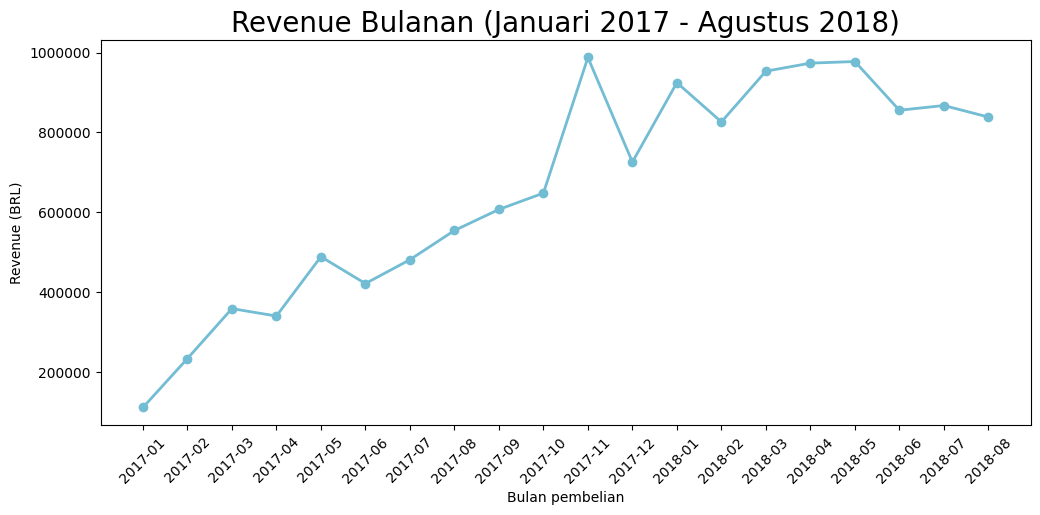

In [51]:
# Grafik garis: revenue tiap bulan
monthly_df = all_df.groupby(by="order_month").revenue.sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_df["order_month"], monthly_df["revenue"], marker="o", linewidth=2, color="#72BCD4")
plt.title("Revenue Bulanan (Januari 2017 - Agustus 2018)", loc="center", fontsize=20)
plt.xlabel("Bulan pembelian")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

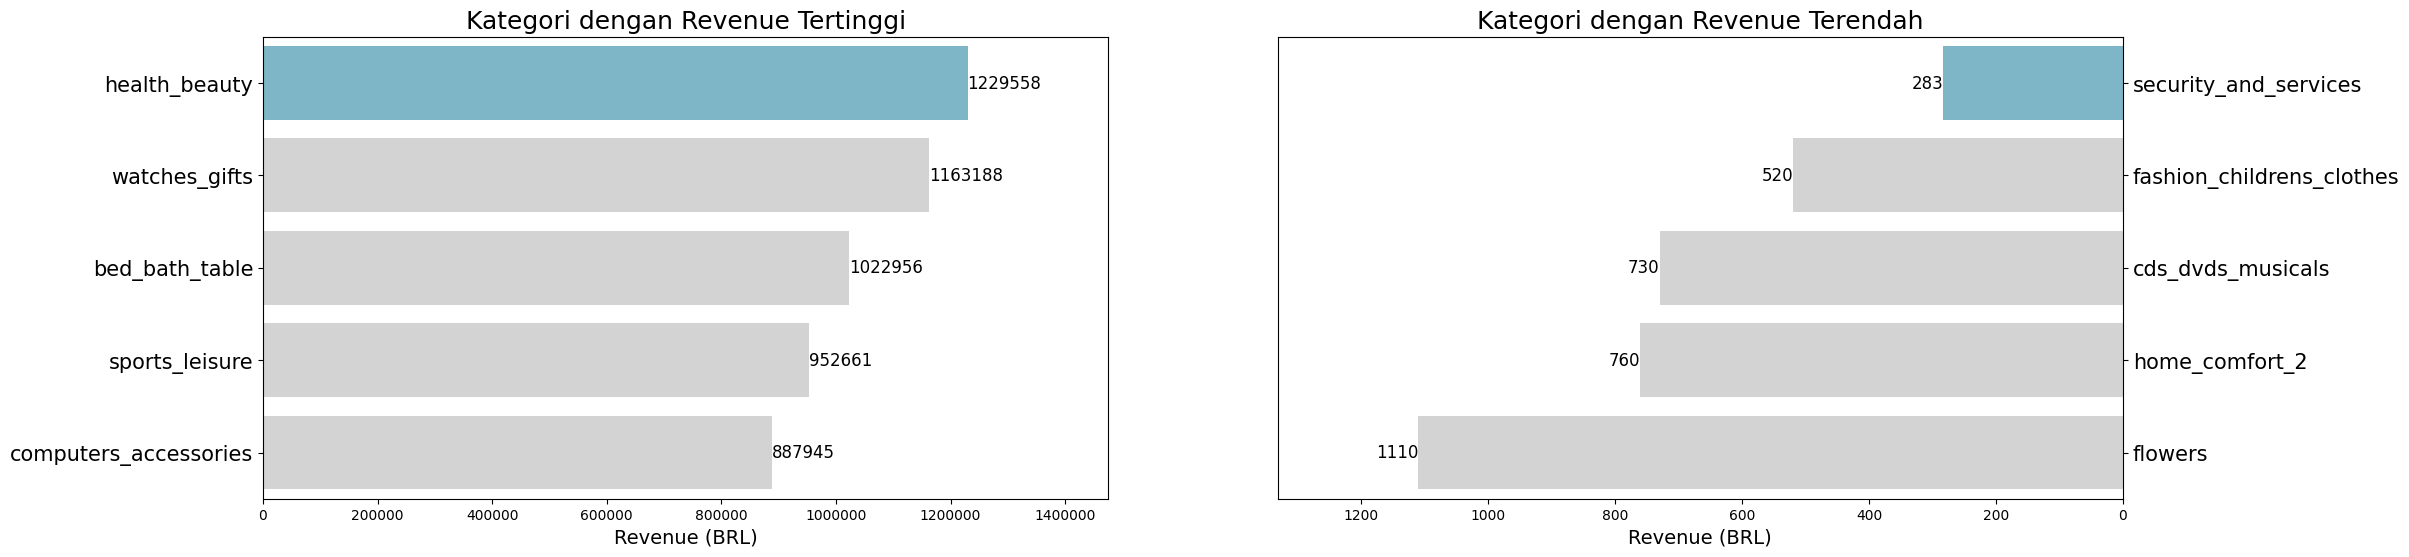

In [52]:
# Grafik batang: 5 kategori dengan revenue tertinggi (kiri) dan terendah (kanan)
category_df = all_df.groupby(by="product_category_name_english").revenue.sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="revenue", y="product_category_name_english", data=category_df.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Revenue (BRL)", fontsize=14)
ax[0].set_title("Kategori dengan Revenue Tertinggi", loc="center", fontsize=18)
ax[0].tick_params(axis="y", labelsize=15)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.0f", fontsize=12)
ax[0].margins(x=0.2)
ax[0].ticklabel_format(style="plain", axis="x")

sns.barplot(x="revenue", y="product_category_name_english", data=category_df.sort_values(by="revenue", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Revenue (BRL)", fontsize=14)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Kategori dengan Revenue Terendah", loc="center", fontsize=18)
ax[1].tick_params(axis="y", labelsize=15)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.0f", fontsize=12)
ax[1].margins(x=0.2)

plt.show()

### Pertanyaan 2: Seberapa besar keterlambatan menurunkan review score, dan di state mana pesanan paling sering terlambat?

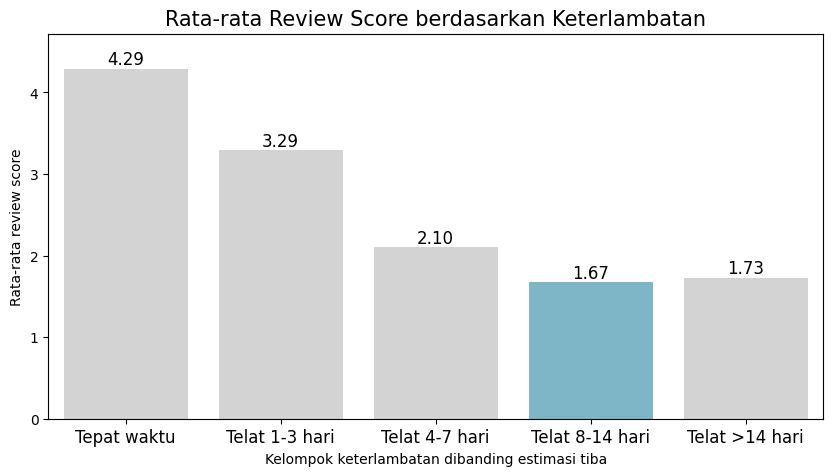

In [53]:
# Grafik batang: rata-rata review score tiap kelompok keterlambatan
delay_df = orders_reviews_df.groupby(by="delay_group").review_score.mean().reset_index()

plt.figure(figsize=(10, 5))
colors_ = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#72BCD4", "#D3D3D3"]  # biru = review terendah

sns.barplot(x="delay_group", y="review_score", data=delay_df, palette=colors_)
plt.title("Rata-rata Review Score berdasarkan Keterlambatan", loc="center", fontsize=15)
plt.xlabel("Kelompok keterlambatan dibanding estimasi tiba")
plt.ylabel("Rata-rata review score")
plt.tick_params(axis="x", labelsize=12)
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.2f", fontsize=12)
plt.margins(y=0.1)
plt.show()

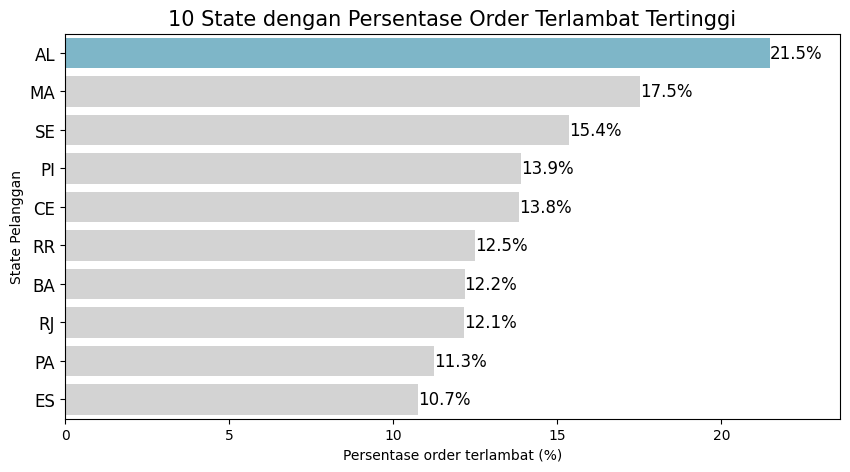

In [54]:
# Grafik batang: 10 state dengan persentase order terlambat tertinggi
state_late_df = state_df.reset_index().head(10)  # state_df sudah diurutkan berdasarkan persentase terlambat

plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="is_late", y="customer_state", data=state_late_df, palette=colors_)
plt.title("10 State dengan Persentase Order Terlambat Tertinggi", loc="center", fontsize=15)
plt.xlabel("Persentase order terlambat (%)")
plt.ylabel("State Pelanggan")
plt.tick_params(axis="y", labelsize=12)
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f%%", fontsize=12)
plt.margins(x=0.1)
plt.show()

**Insight:** (Opsional)
- Revenue naik dari sekitar BRL 112 rb (Januari 2017) menjadi BRL 988 rb (November 2017), lalu relatif stabil di 2018.
- Lima kategori teratas menyumbang sekitar 40% revenue, sedangkan lima kategori terbawah tidak berkontribusi.
- Semakin lama pesanan terlambat, semakin rendah review: 4,29 (tepat waktu), 3,29 (telat 1-3 hari), 2,10 (4-7 hari), dan sekitar 1,7 (lebih dari 7 hari).
- State dengan persentase keterlambatan tertinggi adalah AL (21,5%), MA (17,5%), SE (15,4%), PI (13,9%), dan CE (13,8%). Angka ini jauh di atas rata-rata nasional 6,8%.

## Analisis Lanjutan (Opsional)

### RFM Analysis
RFM Analysis mengelompokkan pelanggan berdasarkan perilaku belanjanya:
- **Recency:** berapa hari sejak pelanggan terakhir berbelanja.
- **Frequency:** berapa kali pelanggan berbelanja.
- **Monetary:** berapa total uang yang dibelanjakan pelanggan.

Tujuannya agar kita tahu pelanggan mana yang terbaik untuk setiap parameter.

In [55]:
# Menghitung Recency, Frequency, dan Monetary tiap pelanggan
rfm_df = all_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",  # tanggal order terakhir
    "order_id": "nunique",
    "revenue": "sum"
})
rfm_df.columns = ["customer_unique_id", "max_order_timestamp", "frequency", "monetary"]

# menghitung kapan terakhir pelanggan melakukan transaksi (hari)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = all_df["order_purchase_timestamp"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,customer_unique_id,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,114
2,0000f46a3911fa3c0805444483337064,1,69.00,537
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,321
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,288


In [56]:
# Melihat persentase pelanggan yang membeli lebih dari sekali dan ringkasan angka RFM
print("Persentase pelanggan yang berbelanja lebih dari sekali: ", round((rfm_df.frequency > 1).mean() * 100, 2), "%")
rfm_df.describe()

Persentase pelanggan yang berbelanja lebih dari sekali:  3.0 %


,frequency,monetary,recency
count,93096.000000,93096.000000,93096.000000
mean,1.033374,141.571904,236.248281
std,0.209021,215.768405,150.944433
min,1.000000,0.850000,0.000000
25%,1.000000,47.650000,114.000000
50%,1.000000,89.700000,218.000000
75%,1.000000,154.162500,345.000000
max,15.000000,13440.000000,601.000000


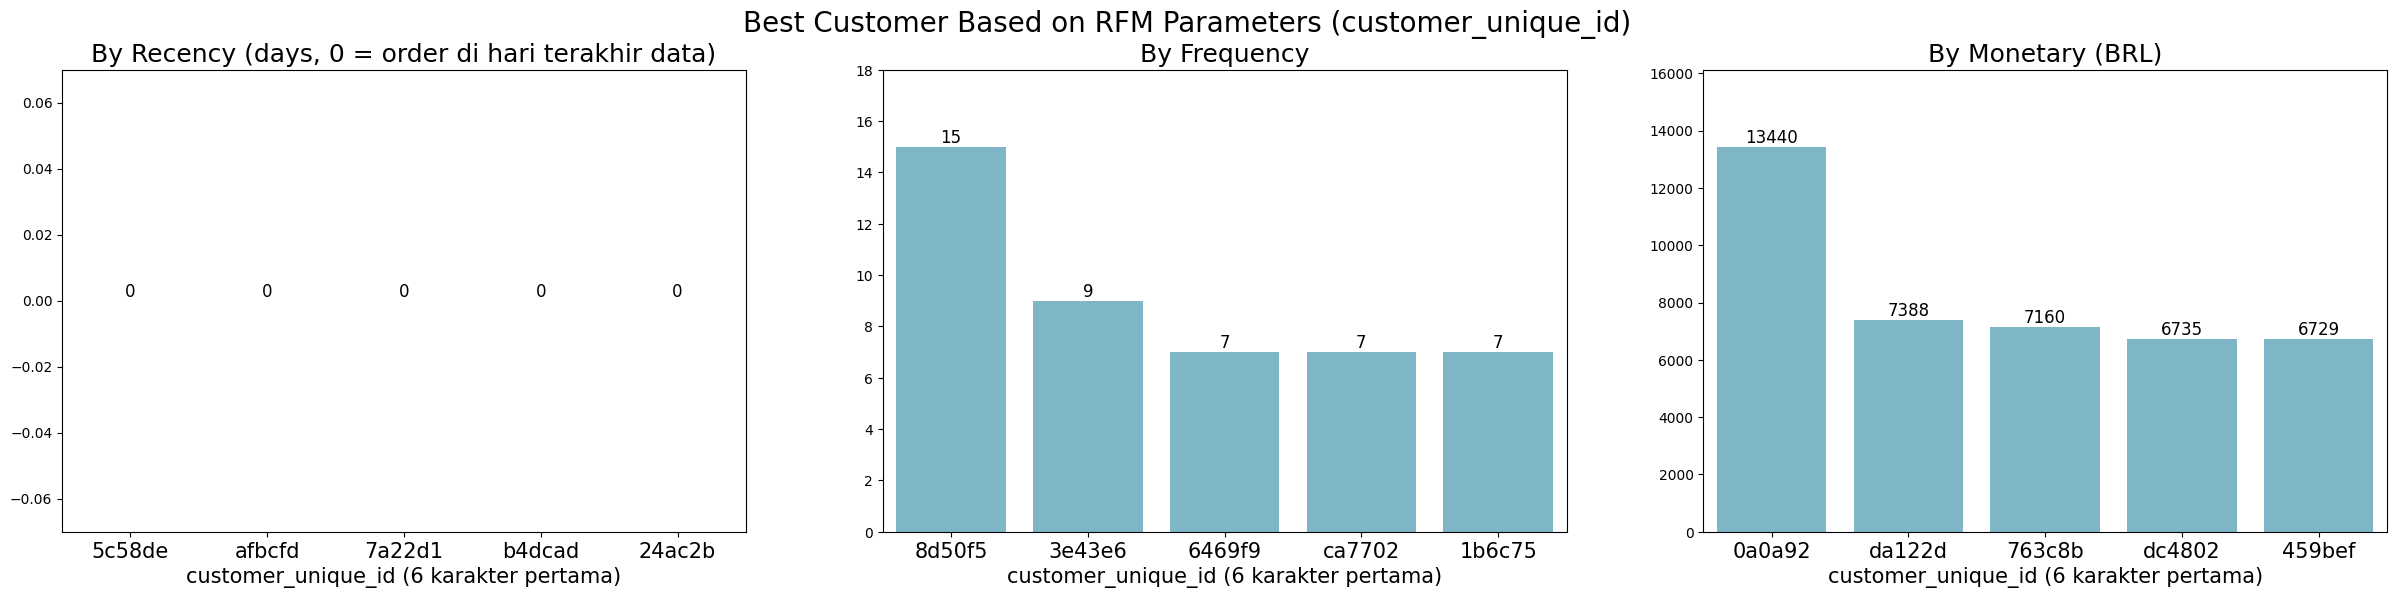

In [57]:
# Grafik batang: 5 pelanggan terbaik untuk Recency, Frequency, dan Monetary
rfm_df["short_id"] = rfm_df["customer_unique_id"].str[:6]  # ID dipersingkat agar label terbaca

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))
colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(y="recency", x="short_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("customer_unique_id (6 karakter pertama)", fontsize=15)
ax[0].set_title("By Recency (days, 0 = order di hari terakhir data)", loc="center", fontsize=18)
ax[0].tick_params(axis="x", labelsize=15)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.0f", fontsize=12)
ax[0].margins(y=0.2)

sns.barplot(y="frequency", x="short_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("customer_unique_id (6 karakter pertama)", fontsize=15)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis="x", labelsize=15)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.0f", fontsize=12)
ax[1].margins(y=0.2)

sns.barplot(y="monetary", x="short_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel("customer_unique_id (6 karakter pertama)", fontsize=15)
ax[2].set_title("By Monetary (BRL)", loc="center", fontsize=18)
ax[2].tick_params(axis="x", labelsize=15)
for container in ax[2].containers:
    ax[2].bar_label(container, fmt="%.0f", fontsize=12)
ax[2].margins(y=0.2)

plt.suptitle("Best Customer Based on RFM Parameters (customer_unique_id)", fontsize=20)
plt.show()

#### Segmentasi Pelanggan berdasarkan RFM

Tabel RFM di atas menunjukkan pelanggan terbaik per parameter. Agar bisa ditindaklanjuti, pelanggan dikelompokkan ke dalam 4 segmen menggunakan **manual grouping** berbasis skor RFM:
- **Recency score (1-5):** dihitung dengan binning kuantil (`pd.qcut`); skor 5 = baru saja berbelanja.
- **Monetary score (1-5):** binning kuantil; skor 5 = belanja terbesar.
- **Frequency:** mayoritas pelanggan hanya berbelanja 1 kali, jadi pelanggan cukup dibedakan menjadi yang berbelanja ulang (2 kali atau lebih) dan yang belanja sekali.

Aturan segmen:
- **Loyal Customers:** berbelanja 2 kali atau lebih.
- **Recent Customers:** belanja 1 kali dan belum lama berbelanja (recency score 3 - 5).
- **At Risk Big Spenders:** belanja 1 kali, sudah lama tidak berbelanja (recency score 1 - 2), dan belanjanya besar (monetary score 4 - 5).
- **Lapsed Customers:** belanja 1 kali, sudah lama tidak berbelanja (recency score 1 - 2), dan belanjanya kecil atau sedang (monetary score 1 - 3).

In [58]:
# Memberi skor recency & monetary (1-5), lalu mengelompokkan pelanggan ke dalam 4 segmen
rfm_df["r_score"] = pd.qcut(rfm_df["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df["m_score"] = pd.qcut(rfm_df["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def assign_segment(row):
    if row["frequency"] >= 2:
        return "Loyal Customers"
    if row["r_score"] >= 3:
        return "Recent Customers"
    if row["m_score"] >= 4:
        return "At Risk Big Spenders"
    return "Lapsed Customers"

rfm_df["segment"] = rfm_df.apply(assign_segment, axis=1)

segment_df = rfm_df.groupby(by="segment").agg({
    "customer_unique_id": "nunique",
    "recency": "mean",
    "frequency": "mean",
    "monetary": ["mean", "sum"]
})
segment_df.columns = ["jumlah_pelanggan", "avg_recency", "avg_frequency", "avg_monetary", "total_monetary"]
segment_df["persen_pelanggan"] = segment_df["jumlah_pelanggan"] / segment_df["jumlah_pelanggan"].sum() * 100
segment_df["persen_revenue"] = segment_df["total_monetary"] / segment_df["total_monetary"].sum() * 100
segment_df.sort_values(by="jumlah_pelanggan", ascending=False).round(1)

,jumlah_pelanggan,avg_recency,avg_frequency,avg_monetary,total_monetary,persen_pelanggan,persen_revenue
segment,,,,,,,
Recent Customers,54060,132.8,1.0,136.9,7400700.9,58.1,56.2
Lapsed Customers,22502,392.3,1.0,55.7,1254476.4,24.2,9.5
At Risk Big Spenders,13745,391.2,1.0,276.4,3799245.6,14.8,28.8
Loyal Customers,2789,219.1,2.1,260.1,725355.0,3.0,5.5


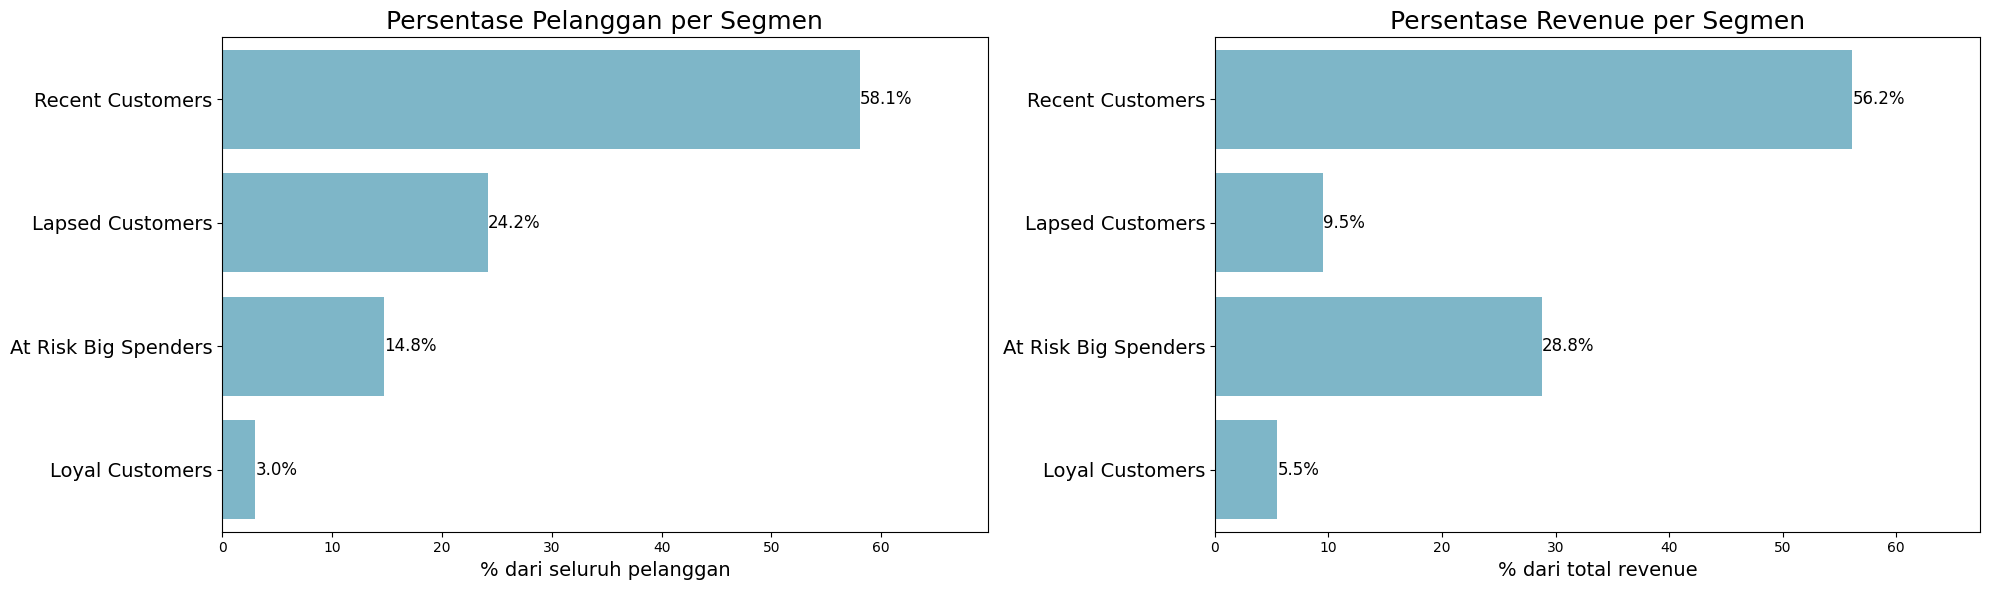

In [59]:
# Grafik batang: persentase pelanggan dan persentase revenue tiap segmen
seg_plot = segment_df.sort_values(by="jumlah_pelanggan", ascending=False).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

sns.barplot(x="persen_pelanggan", y="segment", data=seg_plot, color="#72BCD4", ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("% dari seluruh pelanggan", fontsize=14)
ax[0].set_title("Persentase Pelanggan per Segmen", loc="center", fontsize=18)
ax[0].tick_params(axis="y", labelsize=14)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", fontsize=12)
ax[0].margins(x=0.2)

sns.barplot(x="persen_revenue", y="segment", data=seg_plot, color="#72BCD4", ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("% dari total revenue", fontsize=14)
ax[1].set_title("Persentase Revenue per Segmen", loc="center", fontsize=18)
ax[1].tick_params(axis="y", labelsize=14)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", fontsize=12)
ax[1].margins(x=0.2)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Hanya sekitar 3% pelanggan yang belanja lebih dari satu kali. Mayoritas pelanggan hanya membeli sekali.
- Pelanggan terbaik berdasarkan frequency membeli sampai 15 kali, dan berdasarkan monetary menghabiskan sampai BRL 13.440.
- Segmen **Loyal Customers** (belanja 2 kali atau lebih) hanya 3,0% dari pelanggan dan menyumbang 5,5% revenue.
- Segmen **Recent Customers** paling besar: 58,1% pelanggan dan 56,2% revenue. Mereka baru berbelanja sekali, jadi belum tentu kembali.
- Segmen **Lapsed Customers** (24,2% pelanggan) dan **At Risk Big Spenders** (14,8% pelanggan) sudah sekitar 390 hari tidak berbelanja.
- **At Risk Big Spenders** menyumbang 28,8% revenue. Rata-rata belanja mereka BRL 276, sekitar dua kali lipat Recent Customers (BRL 137), jadi mereka penting untuk diajak berbelanja lagi.

### Menyimpan data untuk dashboard

In [60]:
# Menyimpan data hasil analisis ke file CSV untuk dipakai di dashboard
main_df = all_df[["order_id", "customer_unique_id", "customer_state", "order_purchase_timestamp",
                  "product_category_name_english", "revenue", "review_score", "delay_days", "is_late", "delay_group"]]
main_df.to_csv("main_data.csv", index=False)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Revenue bulanan naik cepat sepanjang 2017, dari BRL 112 ribu di Januari menjadi BRL 988 ribu di November 2017 (puncak). Pada 2018 revenue tidak naik lagi dan bergerak di sekitar BRL 830 - 980 ribu per bulan. Revenue bergantung pada kategori: `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories` yang menyumbang sekitar 40% dari seluruh revenue. Kategori terendah, seperti `security_and_services` (BRL 283) dan `fashion_childrens_clothes` (BRL 520), hampir tidak menghasilkan revenue.
- **Conclusion pertanyaan 2:** Keterlambatan pengiriman membuat review turun tajam. Review rata-rata 4,29 untuk order tepat waktu, turun menjadi 3,29 jika telat 1-3 hari, dan sekitar 1,7 jika telat lebih dari 7 hari. Order paling sering terlambat di state Alagoas/AL (21,5%), Maranhao/MA (17,5%), Sergipe/SE (15,4%), Piaui/PI (13,9%), dan Ceara/CE (13,8%), jauh di atas rata-rata nasional 6,8%.


**Rekomendasi Action Item:**
- **Tim logistik:** memperbaiki pengiriman ke state yang sering terlambat (AL, MA, SE, PI, CE), misalnya dengan menambah gudang yang lebih dekat. Targetnya menekan keterlambatan, karena review sudah turun menjadi 3,3 walau hanya telat 1-3 hari.
- **Tim operasional:** membuat estimasi tiba di state tersebut lebih realistis (lebih panjang) supaya pelanggan tidak kecewa.
- **Tim merchandising:** memfokuskan stok dan promosi pada 5 kategori dengan revenue tertinggi. Evaluasi kategori yang tidak terlalu menghasilkan revenue, apakah perlu dipromosikan atau dihentikan.
- **Tim marketing:** hanya 3% pelanggan yang belanja lebih dari satu kali sehingga perlu dibuat program agar pelanggan kembali membeli (misalnya voucher atau email pengingat). Utamakan segmen **At Risk Big Spenders** (14,8% pelanggan, 28,8% revenue). Ajak juga **Recent Customers** (58,1% pelanggan) untuk membeli lagi sebelum mereka menjadi **Lapsed Customers**.